1030 499


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'camera': {'euler_angles': […

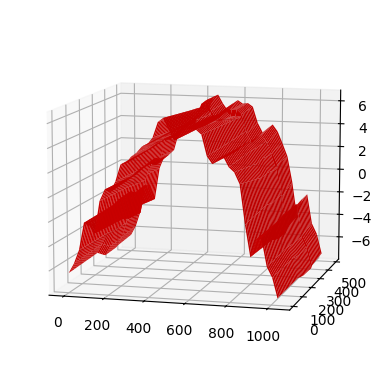

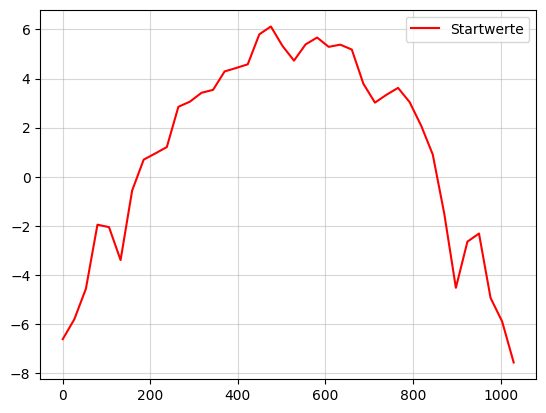

In [2]:
import numpy as np
from math import sqrt
import xyzFile_zusammenrechnen_EW   # greift auf *.py file zu, nicht auf *.ipynb
import xy_KruemmungAnalyse
import HC_AuflagerMinimaViertel

# def Auflager_gemessen(step,filename_MW,tol):
# def Auflager_generiert(l,b,step,tol):
import import_ipynb
import xyzFile_GRAVITATION_Kruemmung
# def gravitationsEinfluss_Auflager(l,b,t,step,auflager_liste,radius):


t = 3.6
tolMinima = 0.9
# MESSWERTE
filename_MW = f"{t}mm_messwerte.xyz"
data_messwerte = np.loadtxt(filename_MW)

# step wird aus Messwerte-File entnommen
step_square = len(data_messwerte[:,0])
if sqrt(step_square)%1 != 0:
    raise ValueError("the Length of the *.xyz-File is not suitable, it should be step*step")

step = int(sqrt(step_square))

# Laenge/Breite wird aus Messwerte-File entnommen
l = int(data_messwerte[-1,0])   #achtung: -1 steht hier für die letzte Zeile, 0 für den x eintrag, 1 für den y eintrag
b = int(data_messwerte[-1,1])
print(l,b)
# r = 35
# r = l/40
r = l*b/40000 # mm    # Radius der Auflager, proportional zu den Maßen der Glasplatte 

#region AUFLAGER total
"""
AuflagerMinima definiert die Mittelpunkte der Auflager-Kreise, indem es den minimalen Z-wert sucht, 
danach alle z-werte sucht, die in einem gewissen Toleranz-bereich liegen und diese als Auflager-Punkte definiert

moegliches Problem: 
die punkte liegen nur in einem kleinen teilgebiet, obwohl auch noch ein anderer auflagerpunkt existiert, 
der aber wegen zu kleiner toleranz nicht gefunden wird

Loesungs-Ansatz:
Toleranz adaptiv nach Laenge/Breite oder Dicke
Gebiet aufteilen (vierteln), siehe unten -> Idee verworfen
"""
auflager_liste = HC_AuflagerMinimaViertel.AuflagerMinima(t,tolMinima)
#endregion

#region AUFLAGER Viertel
"""
AuflagerMinima definiert die Mittelpunkte der Auflager-Kreise, indem es das Gebiet viertelt und in jedem viertel nach Minima sucht, 
damit die Auswirkungen der Gravitation kontrolliert bleiben
"""
# auflager_liste = HC_AuflagerMinimaViertel.AuflagerMinima_viertel(t,tolMinima)
#endregion

#region AUFLAGER mit Kruemmung:

"""
tolKruemmung = 10e-11


AuflagerOrte = xy_KruemmungAnalyse.Auflager_gemessen(step,filename_MW,tol)

# STARTWERTE
# filename_SW = f"{t}mm_startwerte.xyz"
# data_messwerte = np.loadtxt(filename_SW)

# AuflagerOrte = xy_KruemmungAnalyse.Auflager_gemessen(step,filename_SW,tolKruemmung)

print(f"in X-Richtung sind wir {AuflagerOrte[0]} gekrümmt")
print(f"in Y-Richtung sind wir {AuflagerOrte[1]} gekrümmt")

xKruemmung = AuflagerOrte[0]
yKruemmung = AuflagerOrte[1]

if xKruemmung >= 0:
    x1 = l/2
    x2 = l/2
elif xKruemmung < 0:
    x1 = 0
    x2 = l
else:
    print("soll ma da kantenauflager machen?")
    #TODO Kantenauflager?

if yKruemmung >= 0:
    y1 = b/2
    y2 = b/2
elif yKruemmung < 0:
    y1 = 0
    y2 = b
else:
    print("soll ma da kantenauflager machen?")
    #TODO Kantenauflager?


auflager_liste = [(x1+r,y1+r),(x1+r,y2-r),(x2-r,y2-r),(x2-r,y1+r)]
#auflager_liste = [(radius,radius),(l-radius,b-radius),(radius,b-radius),(l-radius,radius)]
"""
#endregion

filename_GRAV = xyzFile_GRAVITATION_Kruemmung.gravitationsEinfluss_Auflager(l,b,t,step,auflager_liste,r)

xyzFile_zusammenrechnen_EW.plotten(l,b,t,step,filename_MW,filename_GRAV)
